In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from scipy.stats import uniform, norm, multivariate_normal
import seaborn as sns 
import multiprocessing as mp
from functools import partial
import time
import copy
import glob
import warnings
warnings.filterwarnings('ignore')
import arviz as az
import pymc as pm
#from main_pool import Main
#from calibr_funcs import plot_results
import calibr_funcs
from networks.model_output import SEIRModelOutput, SEIRParams
from networks.SEIR_network import SEIRNetworkModel
import scipy.stats as stats
from hybrid_network_to_seir import NetworkSEIR_tuned,\
                                    generate_synthetic_data

#pip install -e git+https://github.com/Mpkosh/Mathematics-of-Epidemics-on-Networks.git@my_changes#egg=eon

import plot_funcs
import plot_hyb
import predict_Beta_I
import seir_discrete
import choice_start_day
%load_ext autoreload
%autoreload 2

pm.__version__  

'5.25.1'

## work

In [3]:
'''
'../new_sw_100000\\p_0.5799999999999997_0.3_
0.2_0.0001_0.8000000000000005_seed_0.csv'
'''

true_tau = 0.1
true_alpha = 0.95

init_inf = 1e-4
gamma = 0.3 # latent period rate
delta = 0.2 # recovery rate

days=range(1, 150)

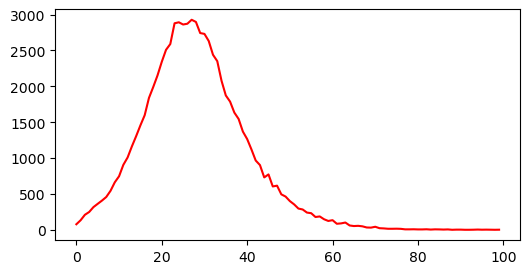

In [4]:
plt.subplots(figsize=(6,3))

observed_data = pd.read_csv('incidence_synthetic_curve.csv'
                           ).iloc[:100]
observed_data.columns=['incidence']

beta_arr = np.arange(0.1, 1, 0.01) #np.arange(0.04, 0.09, 0.01)
alpha_arr = np.arange(0.2, 1, 0.01) #np.arange(0.005, 0.011, 0.001)

plt.plot(observed_data,color='red')

In [13]:
(not False) and (1>0)

True


0.16156599247461806 0.8760162288835832
[1]

0.1494059692052271 0.8945333434284567
[1]

0.15128829480425082 0.8855652941232486
[0]


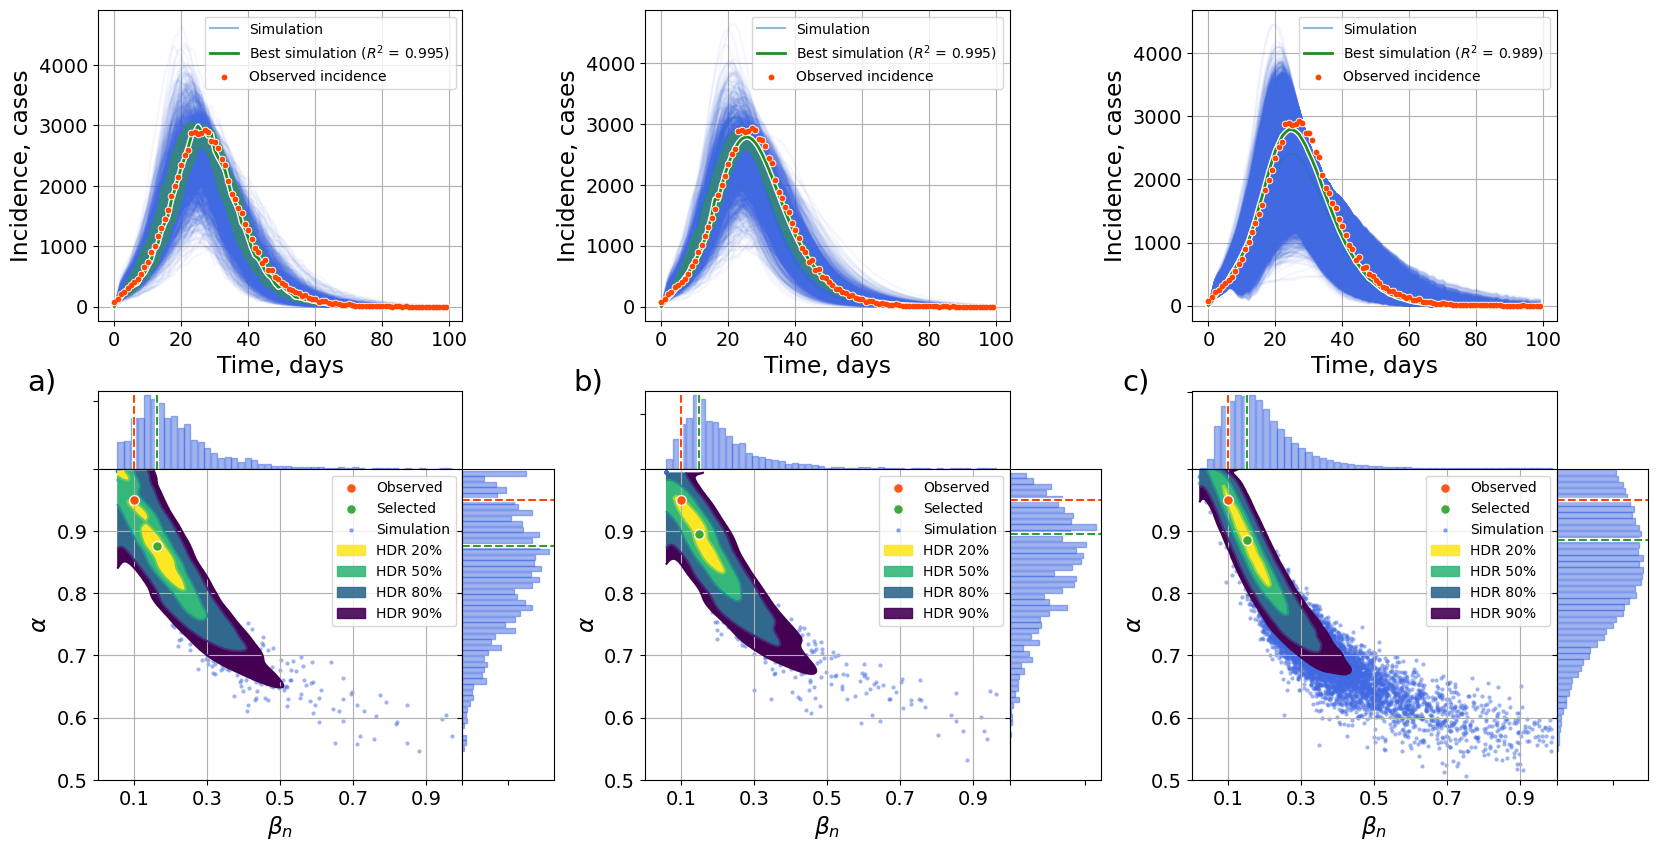

In [32]:
alphabet = 'abcdefghijklmnopqrstuvwxyz'
labels = [alphabet[index] + ')' for index in range(len(alphabet))]

fig = plt.figure(figsize=(20,10))
# adding gridspec
gs = fig.add_gridspec(2, 3, hspace=0.2, width_ratios=[1,1,1],
                     height_ratios=[1,1.25])

# curves subplots
gs00 = gs[0,0].subgridspec(1, 2, width_ratios=[4, 1],
                           wspace=0.)
gs01 = gs[0,1].subgridspec(1, 2, width_ratios=[4, 1],
                          wspace=0.)
gs02 = gs[0,2].subgridspec(1, 2, width_ratios=[4, 1],
                          wspace=0.)

# ufo subplots
gs10 = gs[1,0].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
gs11 = gs[1,1].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
gs12 = gs[1,2].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])

idata14 = az.from_netcdf(f"ba_net_600_3.nc")
idata7 = az.from_netcdf(f"ba_hyb_600_3_s3_r3.nc")
idata0 = az.from_netcdf(f"ba_surr.nc").rename({"beta": "tau"})


with_switch=np.array(False) 
with_df=np.array(False) 
num_runs=[1]
frac=[1]
gamma = 0.3
delta=0.2
n_nodes=100000
network_params=[with_switch,num_runs,frac,gamma,delta,n_nodes]


for gs_0i, gs_1i, idata_i,idx  in zip([gs00,gs01,gs02],
                                 [gs10,gs11,gs12],
                         [idata14,idata7,idata0],
                                     np.arange(3)):

    if idx==1:
        frac=[0.05]
        with_switch=np.array(True) 
        network_params=[with_switch,num_runs,frac,gamma,delta,n_nodes]
    elif idx == 2:
        num_runs = [0]
        frac=[1]
        with_switch=np.array(False) 
        network_params=[with_switch,num_runs,frac,gamma,delta,n_nodes]

    ax_curves = fig.add_subplot(gs_0i[0])

    ax_up = fig.add_subplot(gs_1i[0])
    ax_scatter = fig.add_subplot(gs_1i[2], sharex=ax_up)
    ax_right = fig.add_subplot(gs_1i[3], sharey=ax_scatter)

    plot_funcs.plot_calib(observed_data, idata_i, 
                   true_tau, true_alpha, 
                   network_params, pred=False,
                         ax_curves=[ax_curves],
                         ax_kde=[ax_up,ax_scatter,ax_right])
    fontsize=14
    ax_curves.annotate(labels[idx], xy=(0, 0), xycoords='axes fraction',
                           xytext=(-30, -50), textcoords='offset points',
                           fontsize=1.5*fontsize, ha='right', va='baseline')
    
plt.savefig(f'results/ba_all_appr.pdf', format='pdf', bbox_inches='tight')


0.1494059692052271 0.8945333434284567
[1]


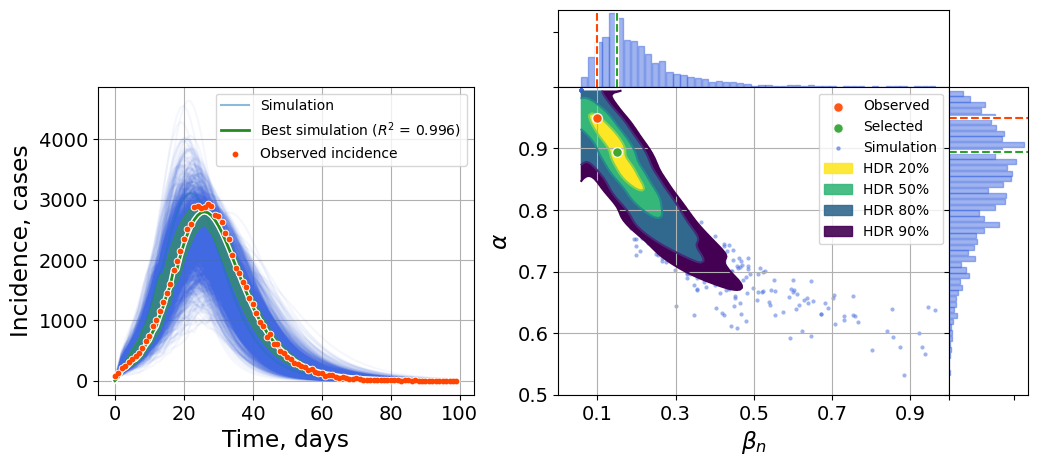

In [31]:
with_switch=np.array(True) 
with_df=[False]
num_runs=[1]
frac=[0.05]
gamma = 0.3
delta=0.2
n_nodes=100000

network_params=[with_switch,num_runs,frac,gamma,delta,n_nodes]

idata = az.from_netcdf(f"ba_hyb_600_3_s3_r3.nc")

plot_funcs.plot_calib(observed_data, idata, 
               true_tau, true_alpha, 
               network_params)


0.16156599247461806 0.8760162288835832
[1]


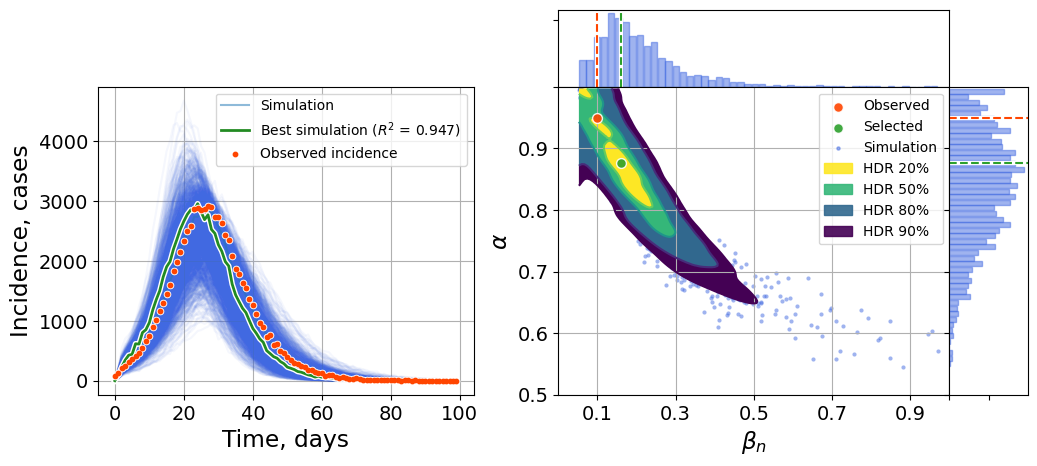

In [26]:
with_switch=np.array(False) 
with_df=[False]
num_runs=[1]
frac=[1]
gamma = 0.3
delta=0.2
n_nodes=100000

network_params=[with_switch,num_runs,frac,gamma,delta,n_nodes]

idata = az.from_netcdf(f"ba_net_600_3.nc")

plot_funcs.plot_calib(observed_data, idata, 
               true_tau, true_alpha, 
               network_params)


CPU times: total: 8.69 s
Wall time: 8.64 s


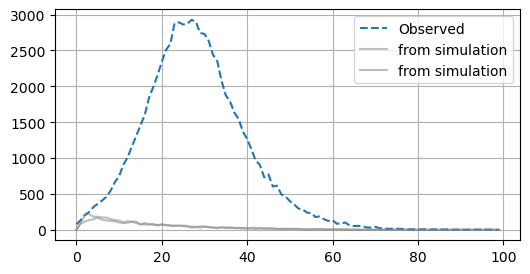

In [30]:
%%time
plt.subplots(figsize=(6,3))
plt.plot(observed_data.incidence, ls='--', label='Observed')

for i in range(2):
    # 0.1, 0.95
    
    q = calibr_funcs.simulation_func(_, tau=[0.50264182], 
                                     alpha=[0.35501375], 
                        modeling_duration=[observed_data.shape[0]], 

                        with_switch=True, num_runs=[1], 
                        frac=[0.05], with_df=[False],
                        size=[observed_data.shape[0]])

    
    plt.plot(q, label='from simulation',color='gray',alpha=.5)

plt.grid()
plt.legend()

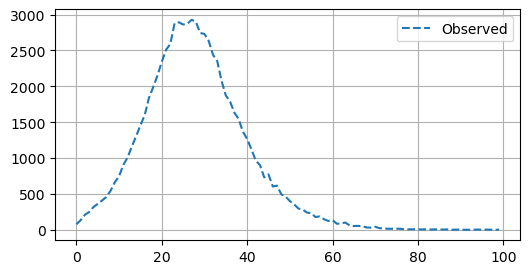

In [8]:

times = []
plt.subplots(figsize=(6,3))
plt.plot(observed_data.incidence, ls='--', label='Observed')

for i in range(100):
    # 0.1, 0.95
    start_time = time.time()
    q = calibr_funcs.simulation_func(_, tau=[0.1], 
                                     alpha=[0.95], 
                        modeling_duration=[observed_data.shape[0]], 

                        with_switch=True, num_runs=[1], 
                        frac=[0.05], with_df=[False],
                        size=[observed_data.shape[0]])
    
    end_time = time.time()
    times.append(end_time-start_time)
    #plt.plot(q, label='from simulation',color='gray',alpha=.5)

plt.grid()
plt.legend()

In [13]:
np.array(times).mean(), np.array(times).std()

(np.float64(3.5104005479812623), np.float64(0.2029213721628136))

<Axes: >

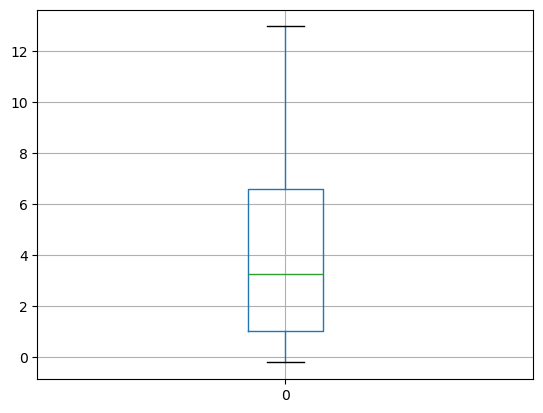

In [16]:
pd.read_csv('../new_ba_100k/time_ba_100000.csv', index_col=0).boxplot()

In [18]:
pd.read_csv('../new_ba_100k/time_ba_100000.csv', index_col=0).sum()

0    286259.857359
dtype: float64

In [19]:
286260 / 60 / 60

79.51666666666667

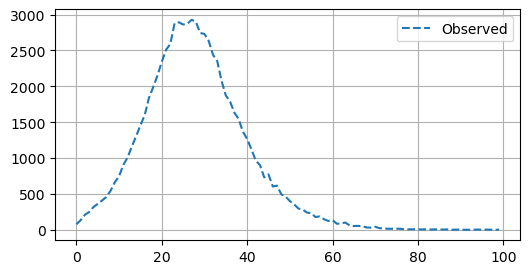

In [9]:

ntimes = []
plt.subplots(figsize=(6,3))
plt.plot(observed_data.incidence, ls='--', label='Observed')

for i in range(100):
    # 0.1, 0.95
    start_time = time.time()
    q = calibr_funcs.simulation_func(_, tau=[0.1], 
                                     alpha=[0.95], 
                        modeling_duration=[observed_data.shape[0]], 

                        with_switch=False, num_runs=[1], 
                        frac=[1], with_df=[False],
                        size=[observed_data.shape[0]])
    
    end_time = time.time()
    ntimes.append(end_time-start_time)
    #plt.plot(q, label='from simulation',color='gray',alpha=.5)

plt.grid()
plt.legend()

In [12]:
np.array(ntimes).mean(), np.array(ntimes).std()

(np.float64(6.833249912261963), np.float64(0.240250262026765))

## check

In [41]:
with_switch=np.array(True) 
with_df=np.array(False) 
num_runs=[1]
frac=[0.05]
gamma = 0.3
delta=0.2
n_nodes=100000

network_params=[with_switch,num_runs,frac,gamma,delta,n_nodes]

idata = az.from_netcdf(f"ba_hyb_{600}_{3}_s3_r3.nc")


0.14940596920522697 0.8945333434284564


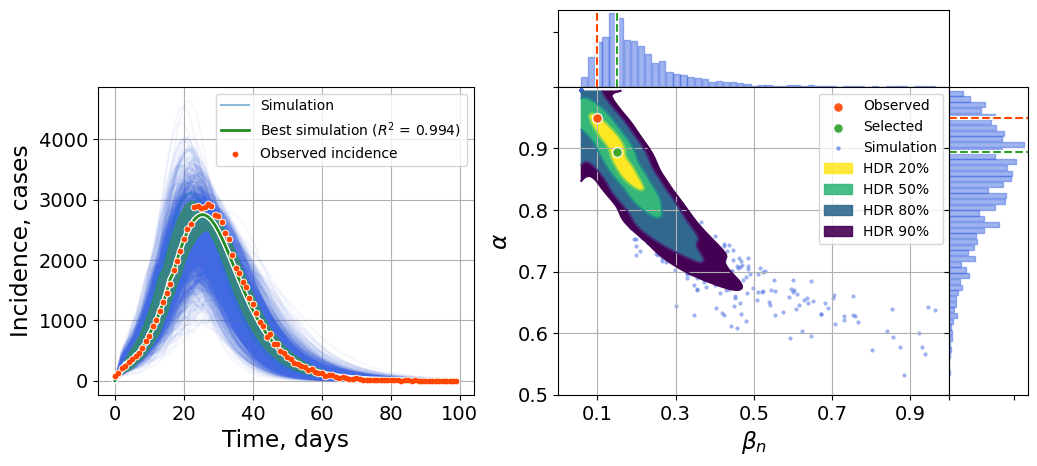

In [42]:
plot_funcs.plot_calib(observed_data, idata, 
               true_tau, true_alpha, 
               network_params)
plt.savefig(f'results/ba_hybrid.pdf', format='pdf', bbox_inches='tight')


0.16156599247461811 0.8760162288835835


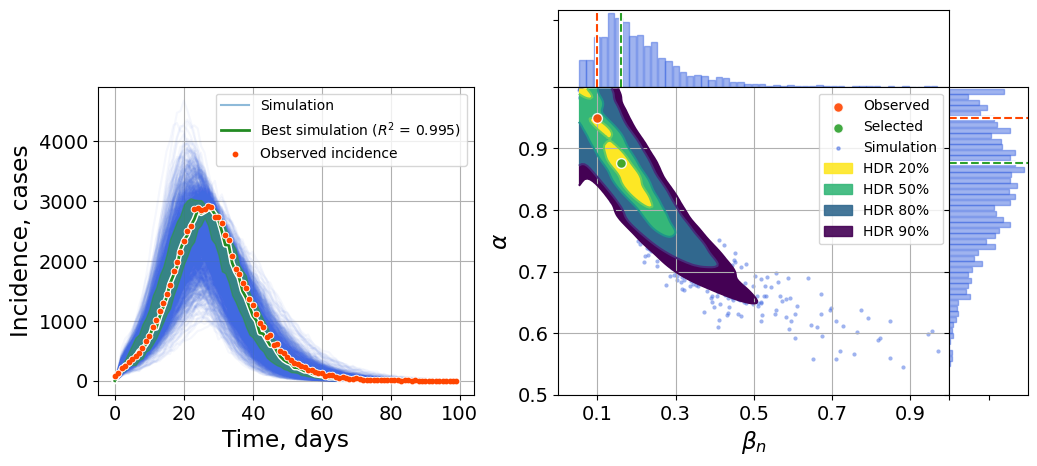

In [40]:
with_switch=np.array(False) 
with_df=[False]
num_runs=[1]
frac=[1]
gamma = 0.3
delta=0.2
n_nodes=100000

network_params=[with_switch,num_runs,frac,gamma,delta,n_nodes]

idata = az.from_netcdf(f"ba_net_600_3.nc")

plot_funcs.plot_calib(observed_data, idata, 
               true_tau, true_alpha, 
               network_params)
plt.savefig(f'results/ba_network.pdf', format='pdf', bbox_inches='tight')


0.33198993349047357 0.7018917114413789

0.3124724971578575 0.7423251112435076

0.1620067237545388 0.8782593609415166


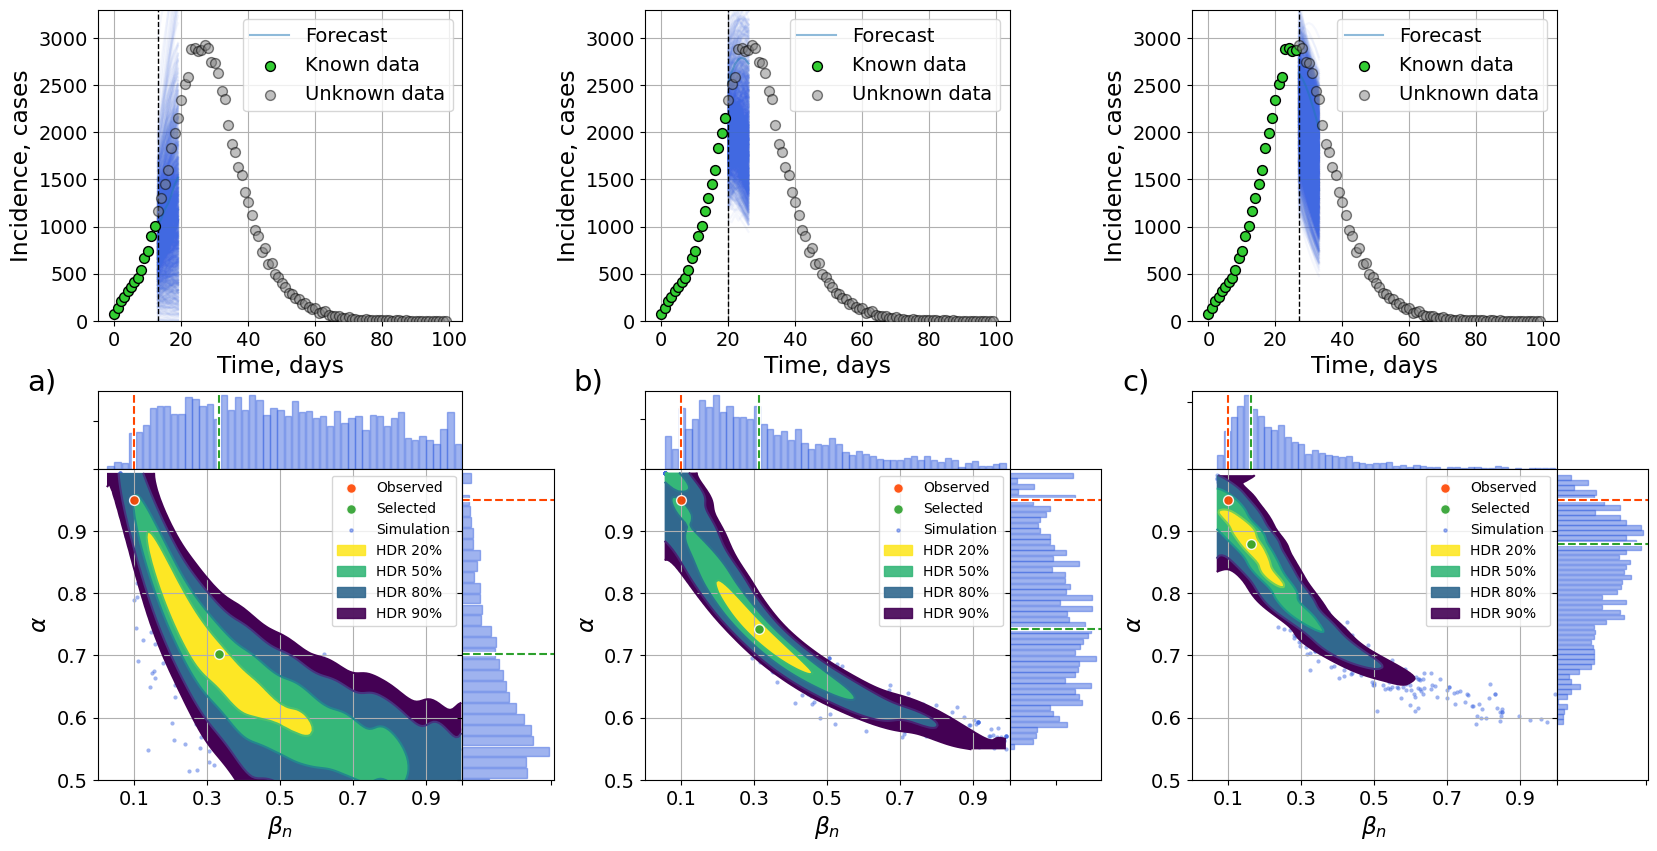

In [43]:
alphabet = 'abcdefghijklmnopqrstuvwxyz'
labels = [alphabet[index] + ')' for index in range(len(alphabet))]

fig = plt.figure(figsize=(20,10))
# adding gridspec
gs = fig.add_gridspec(2, 3, hspace=0.2, width_ratios=[1,1,1],
                     height_ratios=[1,1.25])

# curves subplots
gs00 = gs[0,0].subgridspec(1, 2, width_ratios=[4, 1],
                           wspace=0.)
gs01 = gs[0,1].subgridspec(1, 2, width_ratios=[4, 1],
                          wspace=0.)
gs02 = gs[0,2].subgridspec(1, 2, width_ratios=[4, 1],
                          wspace=0.)

# ufo subplots
gs10 = gs[1,0].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
gs11 = gs[1,1].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
gs12 = gs[1,2].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])

idata14 = az.from_netcdf(f"ba_hyb_600_3_pred_14_eps_500.nc")
idata7 = az.from_netcdf(f"ba_hyb_600_3_pred_7_eps_500.nc")
idata0 = az.from_netcdf(f"ba_hyb_600_3_pred_p.nc")

for gs_0i, gs_1i, idata_i,idx  in zip([gs00,gs01,gs02],
                                 [gs10,gs11,gs12],
                         [idata14,idata7,idata0],
                                     np.arange(3)):
    
    ax_curves = fig.add_subplot(gs_0i[0])

    ax_up = fig.add_subplot(gs_1i[0])
    ax_scatter = fig.add_subplot(gs_1i[2], sharex=ax_up)
    ax_right = fig.add_subplot(gs_1i[3], sharey=ax_scatter)

    plot_funcs.plot_calib(observed_data, idata_i, 
                   true_tau, true_alpha, 
                   network_params, pred=True,
                         ax_curves=[ax_curves],
                         ax_kde=[ax_up,ax_scatter,ax_right])
    fontsize=14
    ax_curves.annotate(labels[idx], xy=(0, 0), xycoords='axes fraction',
                           xytext=(-30, -50), textcoords='offset points',
                           fontsize=1.5*fontsize, ha='right', va='baseline')
    
plt.savefig(f'results/ba_pred_eps1000.pdf', format='pdf', bbox_inches='tight')

In [103]:
ax_curves.get_figure().get_size_inches()

array([20., 10.])


0.1620067237545388 0.8782593609415166


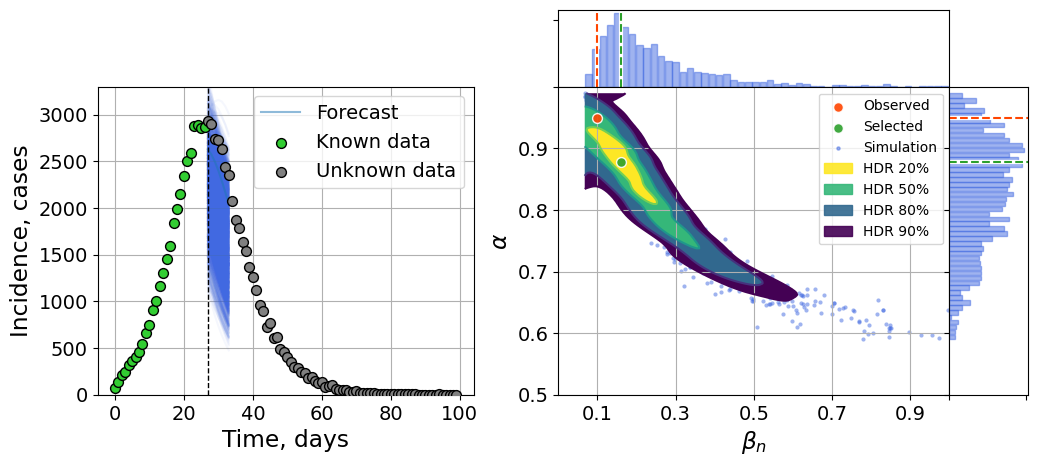

In [30]:
idatat = az.from_netcdf(f"ba_hyb_600_3_pred_p.nc")

plot_funcs.plot_calib(observed_data, idatat, 
               true_tau, true_alpha, 
               network_params, pred=True)


0.24941366262348114 0.7851297493806726


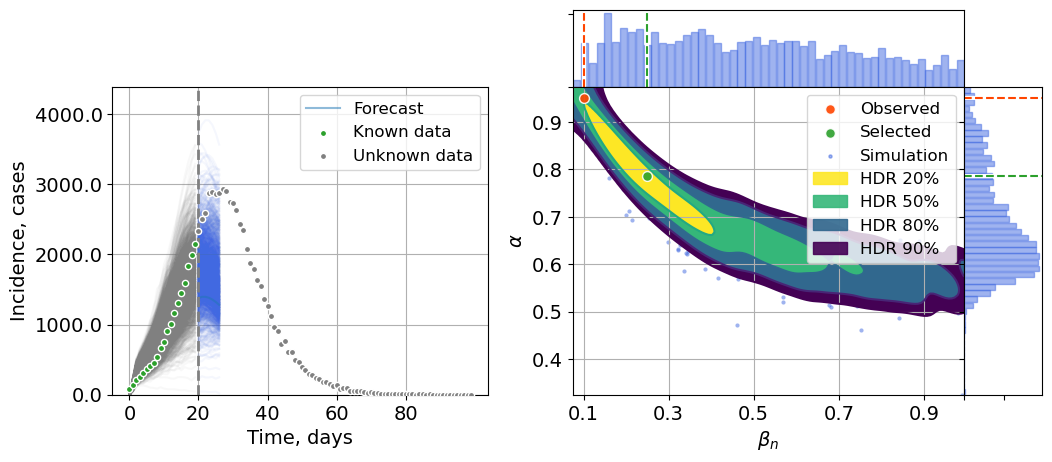

In [125]:
idatat = az.from_netcdf(f"ba_hyb_600_3_pred_7.nc")
plot_funcs.plot_calib(observed_data, idatat, 
               true_tau, true_alpha, 
               network_params, pred=True)


0.5204198756430205 0.607442138478481


AttributeError: PathCollection.set() got an unexpected keyword argument 'size'

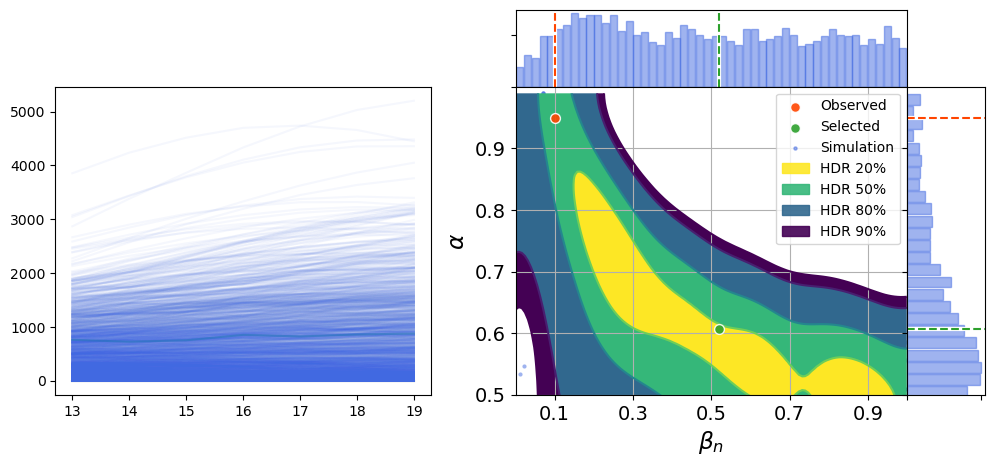

In [20]:
idatat = az.from_netcdf(f"ba_hyb_600_3_pred_14.nc")

plot_funcs.plot_calib(observed_data, idatat, 
               true_tau, true_alpha, 
               network_params, pred=True)

In [130]:
int(observed_data['incidence'].max())*1.5

4392.0

In [20]:
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import matplotlib as mpl
import matplotlib.patches as mpatches

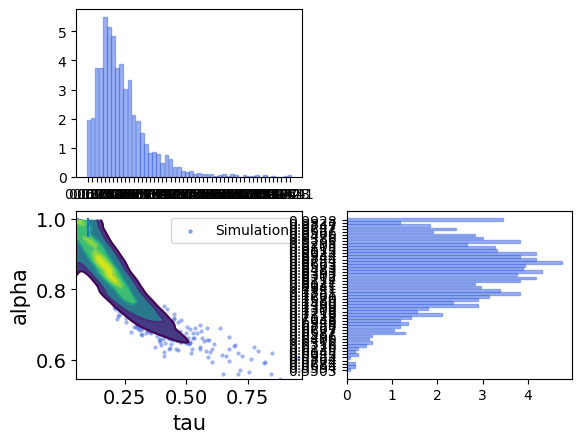

In [24]:
cmap = mpl.colormaps['viridis']
hdi_list = [0.1,0.2,0.5,0.8,0.9]
colors_l = cmap(np.linspace(0, 1, len(hdi_list)))

# for edgecolor to have alpha
fc=to_rgba('RoyalBlue', 0.5)
param_names = ['tau','alpha']  
fancy_names = [r'$\beta_n$', r'$\alpha$']
    
fig, ax=plt.subplots(2,2)    
az.plot_pair(
   idata,
        var_names=["tau", "alpha"],
        kind=["scatter", "kde"],
        kde_kwargs={"fill_last": False, 
                    'hdi_probs':hdi_list,
                    'fill_kwargs':{'alpha': .1},
                    'contour_kwargs':{"colors":None},
                    'contourf_kwargs':{"alpha":0}},
        marginals=True,
        #point_estimate="mode",
        #reference_values={'tau':true_tau, 'alpha': true_alpha},
        #reference_values_kwargs={'color':'red'},
        marginal_kwargs={'kind':'hist','hist_kwargs':{'bins':50,
                                                      'color':fc,
                                                     #'alpha':.5,
                                                     'ec':fc}},
        scatter_kwargs={'color':fc},
        ax=ax
)

ls3 = ax[1,0].scatter(true_tau, true_alpha, zorder=0, s=5,
               color=fc, label='Simulation')
ax[1,0].legend(handles=[ls3])

ax[1,0].plot([true_tau, true_tau], [true_alpha, 1])
ax[1,0].plot([true_tau, true_alpha], [true_alpha, 1])

In [27]:
idata.posterior['alpha'].stack(samples=("draw", "chain")).values

array([0.92189199, 0.8364203 , 0.79411576, ..., 0.83915092, 0.78169071,
       0.94664939], shape=(1800,))

In [39]:
 idata.posterior['alpha'].stack(samples=("draw", "chain")).values.shape

(1800,)

In [38]:
az.plots.plot_utils.calculate_point_estimate('mode', 
                                             idata.posterior['alpha'].stack(samples=("draw", "chain")
                                                                           ).values,
                                            bw=4.5
                                            )

np.float64(0.8698549948674443)

In [30]:
az.plots.plot_utils.calculate_point_estimate('mode', 
                                             idata.posterior['tau'].stack(samples=("draw", "chain")
                                                                           ).values,
                                             #bw=4.5
                                            )

np.float64(0.15077334635882464)

array([[<Axes: >, None],
       [<Axes: xlabel='tau', ylabel='alpha'>, <Axes: >]], dtype=object)

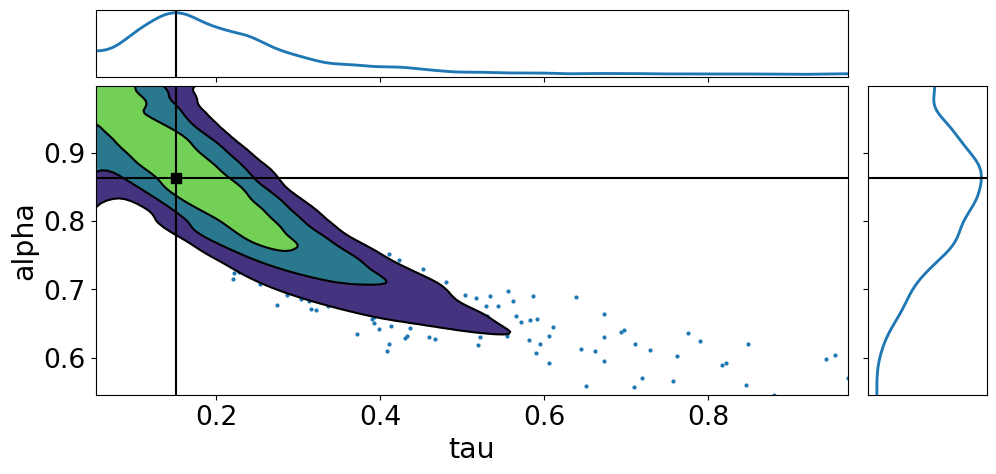

## hm

In [96]:
# create
network_params = {'n_nodes': 100000,
                  'network_type': 'ba'}
#observed_prv = observed_data[['incidence']]
hn = NetworkSEIR_tuned(observed_data, network_params,
                       fixed_sigma=gamma, 
                       fixed_gamma=delta)

'''

true_tau = 0.1
true_alpha = 0.95
'''
# define parameter ranges for priors
prior_ranges = {"tau": (0.57, 0.59),  
                "alpha": (0.79, 0.81) 
                }

start_time = time.time()
# run History Matching
hm_results = hn.history_matching(prior_ranges, 
                                 n_samples=7200,
                                 adaptive=True, 
                                 accept_ratio=.02,
                                 prepared=True, 
                                 folder='../hybrid_surrogate/sim_data/new_sw_100000/',
                                 file = 'data_ba_100000.csv')
end_time = time.time()

print('It took: ', end_time - start_time)

Network SEIR - Fixed parameters: sigma = 0.3, gamma = 0.2
Calibrating parameters
Running Network SEIR history matching with 7200 samples...
Accepted 144 parameter sets
It took:  5.553905487060547


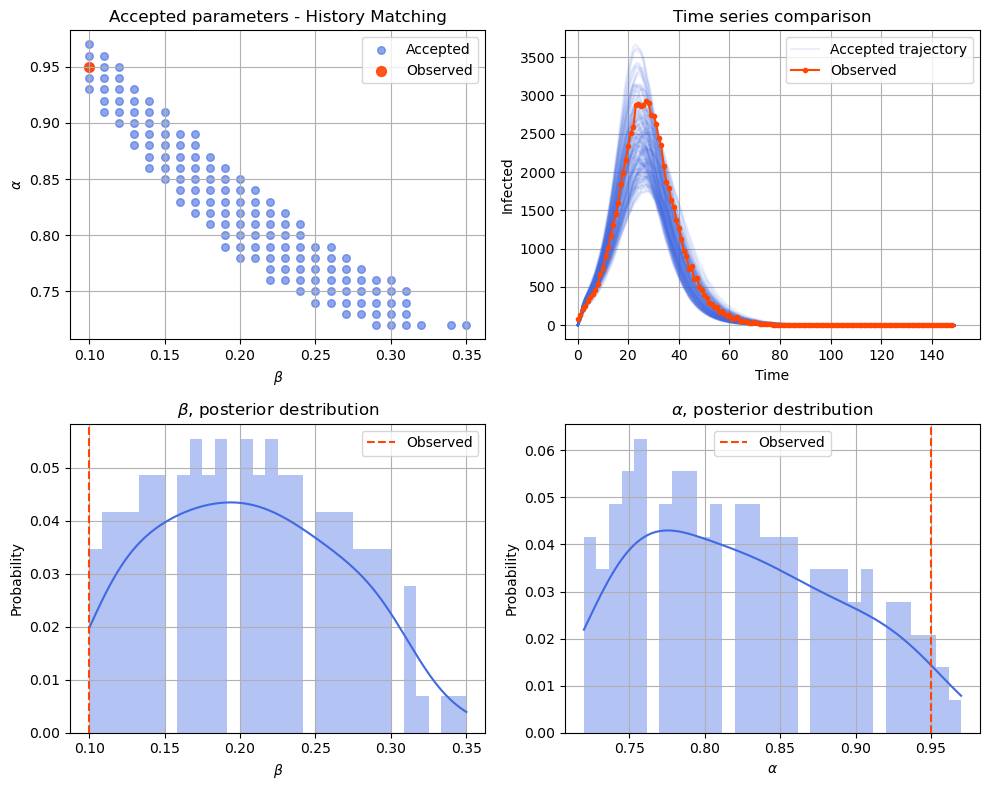

In [97]:
plot_results(observed_data, hm_results, 
             "History Matching", n_trajectories=len(hm_results),
             true_p0=true_tau, true_p1=true_alpha)

plt.savefig(f'results/hmba.pdf', format='pdf', bbox_inches='tight')

In [98]:
hm_results['tau'].quantile(.01), hm_results['tau'].quantile(.99)

(np.float64(0.1), np.float64(0.33139999999999986))

In [99]:
hm_results['tau'].min(), hm_results['tau'].max()

(np.float64(0.1), np.float64(0.35))

In [134]:
hm_results['alpha'].min(), hm_results['alpha'].max()

(np.float64(0.72), np.float64(0.97))

In [102]:
hm_results.head()

,tau,alpha,distance,trajectory
154,0.11,0.94,22.261074,"[0.0, 64.4, 167.5, 228.9, 292.4, 353.1, 414.4,..."
390,0.14,0.90,22.343624,"[0.0, 74.1, 185.5, 251.2, 307.8, 367.1, 434.3,..."
232,0.12,0.92,24.069799,"[0.0, 68.2, 167.7, 234.6, 289.8, 358.7, 400.8,..."
311,0.13,0.91,30.273826,"[0.0, 70.2, 177.3, 254.1, 332.1, 389.9, 447.6,..."
75,0.10,0.95,31.273826,"[0.0, 65.2, 149.8, 211.9, 266.7, 321.7, 375.3,..."


## checking

CPU times: total: 59.8 s
Wall time: 60 s


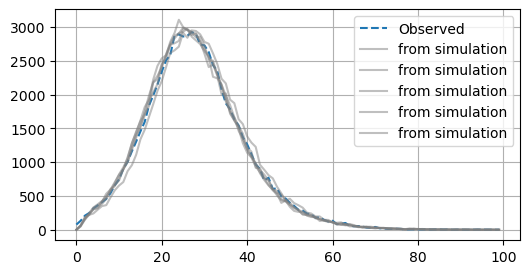

In [9]:
%%time
plt.subplots(figsize=(6,3))
plt.plot(observed_data.incidence, ls='--', label='Observed')

for i in range(5):
    # 0.1, 0.95
    q = calibr_funcs.simulation_func(_, tau=[0.1], 
                                     alpha=[0.95], 
                        modeling_duration=[observed_data.shape[0]], 

                        with_switch=False, num_runs=[1], 
                        frac=[1], size=[observed_data.shape[0]])

    
    plt.plot(q, label='from simulation',color='gray',alpha=.5)

plt.grid()
plt.legend()

CPU times: total: 27 s
Wall time: 26 s


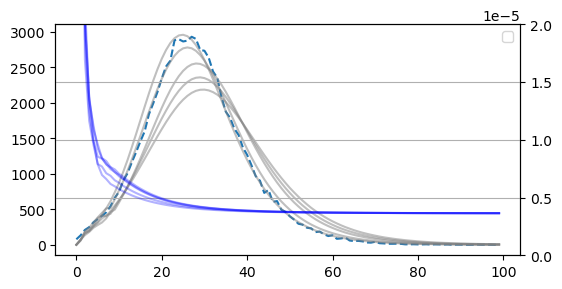

In [11]:
%%time
# 0.1, 0.95
fig, ax = plt.subplots(figsize=(6,3))
axb = ax.twinx()
ax.plot(observed_data.incidence, ls='--', label='Observed')

for i in range(5):
    # 0.1, 0.95
    q,df = calibr_funcs.simulation_func(_, tau=[0.1], 
                                     alpha=[0.95], 
                        modeling_duration=[observed_data.shape[0]], 

                        with_switch=True, num_runs=[1], 
                        frac=[.01], with_df=[True],
                                     size=[observed_data.shape[0]])

    
    ax.plot(q, label='from simulation',color='gray',alpha=.5)
    axb.plot(df.Beta, color='blue', alpha=0.3)


axb.set_ylim(0, 2e-5)    
plt.grid()
plt.legend()

CPU times: total: 29.9 s
Wall time: 29.3 s


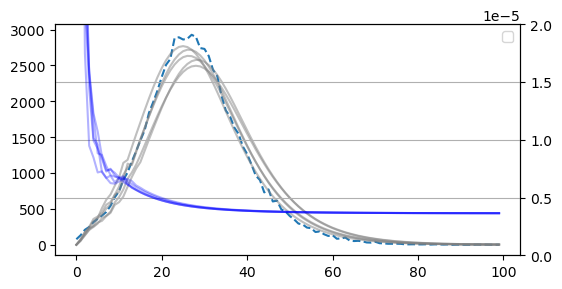

In [12]:
%%time
# 0.1, 0.95
fig, ax = plt.subplots(figsize=(6,3))
axb = ax.twinx()
ax.plot(observed_data.incidence, ls='--', label='Observed')

for i in range(5):
    # 0.1, 0.95
    q,df = calibr_funcs.simulation_func(_, tau=[0.1], 
                                     alpha=[0.95], 
                        modeling_duration=[observed_data.shape[0]], 

                        with_switch=True, num_runs=[1], 
                        frac=[.03], with_df=[True],
                                     size=[observed_data.shape[0]])

    
    ax.plot(q, label='from simulation',color='gray',alpha=.5)
    axb.plot(df.Beta, color='blue', alpha=0.3)


axb.set_ylim(0, 2e-5)    
plt.grid()
plt.legend()

CPU times: total: 31.1 s
Wall time: 30 s


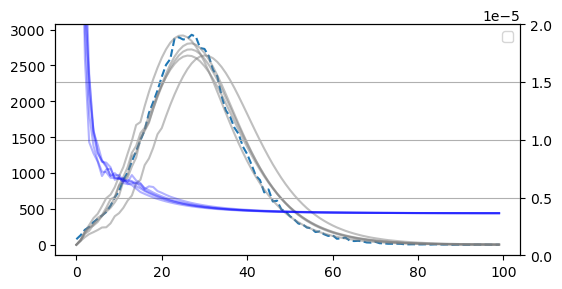

In [13]:
%%time
# 0.1, 0.95
fig, ax = plt.subplots(figsize=(6,3))
axb = ax.twinx()
ax.plot(observed_data.incidence, ls='--', label='Observed')

for i in range(5):
    # 0.1, 0.95
    q,df = calibr_funcs.simulation_func(_, tau=[0.1], 
                                     alpha=[0.95], 
                        modeling_duration=[observed_data.shape[0]], 

                        with_switch=True, num_runs=[1], 
                        frac=[.05], with_df=[True],
                                     size=[observed_data.shape[0]])

    
    ax.plot(q, label='from simulation',color='gray',alpha=.5)
    axb.plot(df.Beta, color='blue', alpha=0.3)


axb.set_ylim(0, 2e-5)    
plt.grid()
plt.legend()

## hybrid; hm

In [ ]:

# 671.4
draws = 30
chains = 3
progressbar = True

'''

'''

with_switch=np.array(True) 
num_runs=[3]
frac=[0.015]
gamma = 0.3
delta=0.2
n_nodes=100000


with pm.Model() as pm_model:
    #alpha_v = pm.Uniform(name="alpha", lower=0.6, upper=0.8375)
    #lmbd_v = pm.Uniform(name="lmbd", lower=0.325, upper=0.5)
    
    p0_v = pm.Uniform(name="tau", 
                      lower=hm_results['tau'].min(),#quantile(.01), 
                      upper=hm_results['tau'].max()#quantile(.99)
                     )
    p1_v = pm.Uniform(name="alpha", 
                      lower=hm_results['alpha'].min(),#quantile(.01), 
                      upper=hm_results['alpha'].max()#quantile(.99)
                     )
    # вынесем, тк для прогноза нужно будет задавать размер
    modeling_duration = len(observed_data) #149
    

    sim = pm.Simulator("sim", simulation_func, 
                        params = (p0_v, p1_v, modeling_duration, 
                                  with_switch, num_runs, frac
                                 ),   
                       
                        epsilon=2000, 
                        #ndims_params=[1,1,1,1,1,1],
                        observed=observed_data['incidence'].values
                      )
    
    # maybe parameter start == mean of HM ?
    #step=pm.DEMetropolisZ()
    
    start_time = time.time()
    idata = pm.sample_smc(#tune=tune, 
                          draws=draws, 
                          cores=6, chains=chains,
                          #step=step, 
                          progressbar=progressbar)
    end_time = time.time()
    
    idata.extend(pm.sample_posterior_predictive(idata,
                                            progressbar=progressbar))

    

# ~40-50 sec per sample
# 4472sec, 2x100, frac=0.01
print('It took ', end_time-start_time, 'sec')

Initializing SMC sampler...
Sampling 3 chains in 3 jobs


In [ ]:
plot_funcs.plots(idata, observed_data['incidence'].values, '', 
                 for_pred=False, with_trace=True)


In [ ]:
plot_funcs.results_calib(observed_data, idata, 
                         true_tau, true_alpha)
plt.savefig(f'results/ba_calib.pdf', format='pdf', bbox_inches='tight')

## network, no hm

In [168]:
19600/60/60

5.444444444444445

In [14]:
# 851.69

draws = 600
chains = 3
progressbar = True

'''

'''

with_switch=np.array(False) 
with_df=[False]
num_runs=[1]
frac=[1]
gamma = 0.3
delta=0.2
n_nodes=100000

network_params=[with_switch,num_runs,frac,gamma,delta,n_nodes]

with pm.Model() as pm_model_t:
    #alpha_v = pm.Uniform(name="alpha", lower=0.6, upper=0.8375)
    #lmbd_v = pm.Uniform(name="lmbd", lower=0.325, upper=0.5)
    real_data = pm.Data("incidence", observed_data['incidence'].values)
    p0_v = pm.Uniform(name="tau", lower=0., upper=1.)
    p1_v = pm.Uniform(name="alpha", lower=0., upper=1.)
    # вынесем, тк для прогноза нужно будет задавать размер
    modeling_duration = len(observed_data) #149
    

    sim = pm.Simulator("sim", calibr_funcs.simulation_func, 
                        params = (p0_v, p1_v, modeling_duration, 
                                  with_switch, num_runs, frac,
                                  with_df
                                 ),   
                       
                       
                        epsilon=2000, 
                        #ndims_params=[1,1,1,1,1,1],
                        observed=real_data
                      )
    
    # maybe parameter start == mean of HM ?
    #step=pm.DEMetropolisZ()
    
    start_time = time.time()
    idata2 = pm.sample_smc(#tune=tune, 
                          draws=draws, 
                          cores=6, chains=chains,
                          #step=step, 
                          progressbar=progressbar)
    end_time = time.time()
    
    idata2.extend(pm.sample_posterior_predictive(idata2,
                                            progressbar=progressbar))

    

# It took  32616.331862449646 sec
print('It took ', end_time-start_time, 'sec')

Initializing SMC sampler...
Sampling 3 chains in 3 jobs


We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [sim]


It took  154481.2739071846 sec


In [17]:
154481/60/60

42.91138888888889

In [6]:
with_switch=np.array(False) 
with_df=[False]
num_runs=[1]
frac=[1]
gamma = 0.3
delta=0.2
n_nodes=100000

network_params=[with_switch,num_runs,frac,gamma,delta,n_nodes]

In [7]:
idata2 = az.from_netcdf(f"ba_net_600_3.nc")

0.152 0.994


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,0.212,0.120,0.056,0.420,0.003,0.004,1292.0,446.0,1.0
alpha,0.835,0.091,0.680,0.997,0.002,0.002,1214.0,453.0,1.0


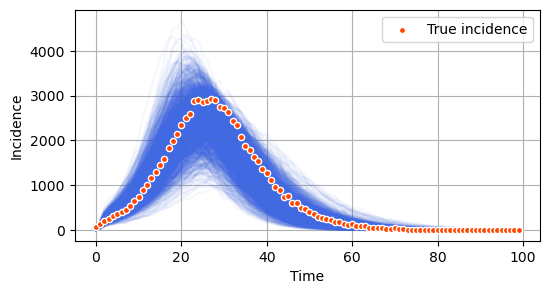

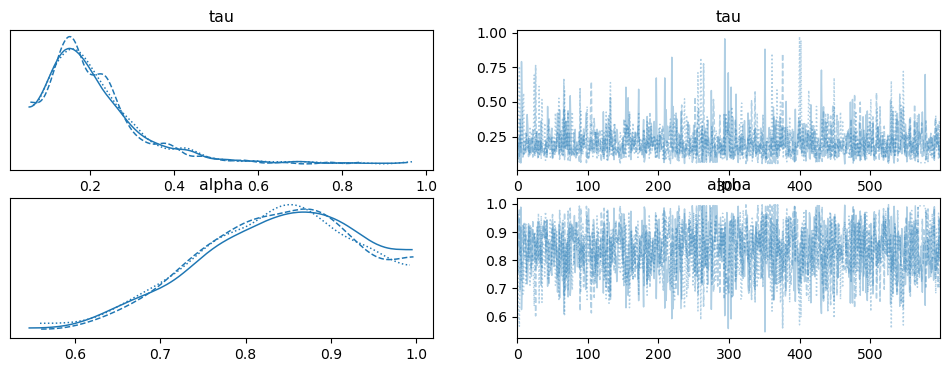

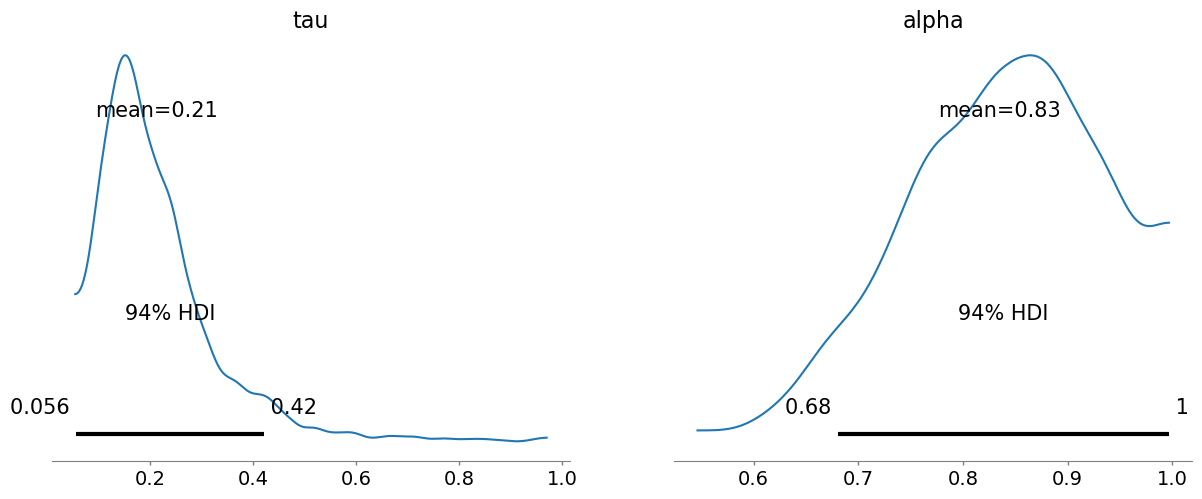

In [9]:
param_names = ['tau','alpha']  
posterior = idata2.posterior.stack(samples=("draw", "chain"))
rr = 3
p0_mode = stats.mode(posterior[param_names[0]].round(rr))[0]
p1_mode = stats.mode(posterior[param_names[1]].round(rr))[0]

plot_funcs.plots(idata2, observed_data['incidence'].values, '', 
                 for_pred=False, with_trace=True,
                 p0_mode=p0_mode,p1_mode=p1_mode,
                 network_params=network_params)


0.16 0.89


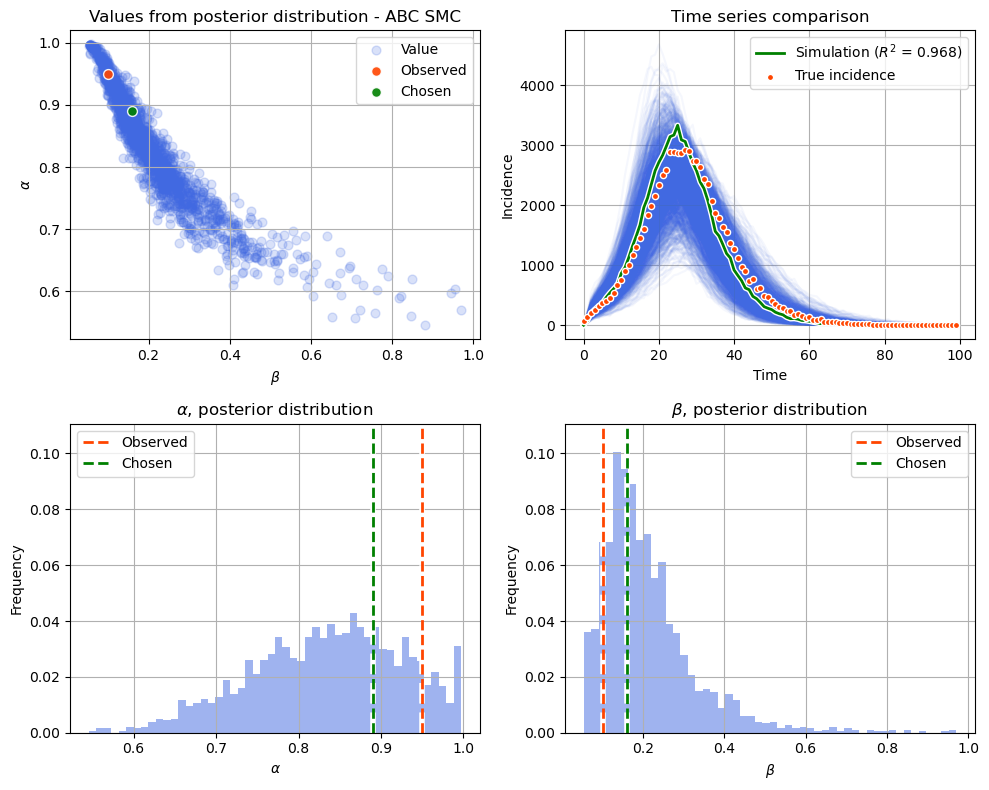

In [21]:
plot_funcs.results_calib(observed_data, idata2, 
                 
                        true_tau, true_alpha,
                        network_params=network_params)
plt.savefig(f'results/ba_network.pdf', format='pdf', bbox_inches='tight')

In [18]:
idata = idata2.copy()

# for string
idata.sample_stats['beta'] = idata.sample_stats['beta'].astype(str)

#idata.to_netcdf(f"ba_net_{draws}_{chains}.nc")

'ba_net_600_3.nc'

## hybrid, no hm

In [22]:
19319/60/60 -- 450

5.366388888888889

In [36]:

# 
draws = 600
chains = 3
progressbar = True

'''

'''

with_switch=np.array(True) 
with_df=np.array(False) 
num_runs=[1]
frac=[0.05]
gamma = 0.3
delta=0.2
n_nodes=100000

network_params=[with_switch,num_runs,frac,gamma,delta,n_nodes]

with pm.Model() as pm_model_t:
    #alpha_v = pm.Uniform(name="alpha", lower=0.6, upper=0.8375)
    #lmbd_v = pm.Uniform(name="lmbd", lower=0.325, upper=0.5)
    real_data = pm.Data("incidence", observed_data['incidence'].values)
    p0_v = pm.Uniform(name="tau", lower=0., upper=1.)
    p1_v = pm.Uniform(name="alpha", lower=0., upper=1.)
    # вынесем, тк для прогноза нужно будет задавать размер
    modeling_duration = len(observed_data) #149
    

    sim = pm.Simulator("sim", calibr_funcs.simulation_func, 
                        params = (p0_v, p1_v, modeling_duration, 
                                  with_switch, num_runs, frac,
                                 with_df),   
                       
                        epsilon=2000, 
                        #ndims_params=[1,1,1,1,1,1],
                        observed=real_data
                      )
    
    # maybe parameter start == mean of HM ?
    #step=pm.DEMetropolisZ()
    
    start_time = time.time()
    idatat = pm.sample_smc(#tune=tune, 
                          draws=draws, 
                          cores=None, 
                          chains=chains,
                          #step=step, 
                          progressbar=progressbar)
    end_time = time.time()
    
    idatat.extend(pm.sample_posterior_predictive(idatat,
                                            progressbar=progressbar))

    

# It took  19319.201872587204 sec
print('It took ', end_time-start_time, 'sec')

Initializing SMC sampler...
Sampling 3 chains in 3 jobs


We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [sim]


It took  91291.72624397278 sec


In [37]:
with_switch=np.array(True) 
with_df=np.array(False) 
num_runs=[1]
frac=[0.05]
gamma = 0.3
delta=0.2
n_nodes=100000

network_params=[with_switch,num_runs,frac,gamma,delta,n_nodes]

[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env2\Lib\site-packages\IPython\extensions\autoreload.py", line 283, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env2\Lib\site-packages\IPython\extensions\autoreload.py", line 483, in superreload
    module = reload(module)
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env2\Lib\importlib\__init__.py", line 128, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


0.15 0.9


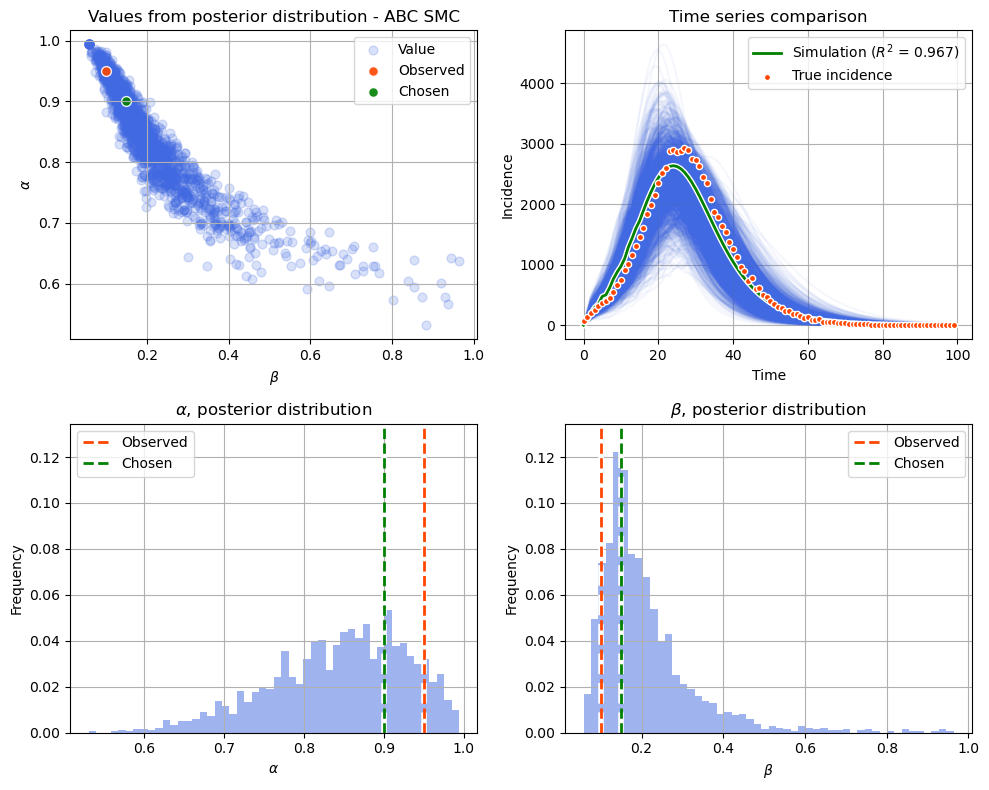

In [38]:
plot_funcs.results_calib(observed_data, idatat, 
                         true_tau, true_alpha, network_params)

In [39]:
idata = idatat.copy()

# for string
idata.sample_stats['beta'] = idata.sample_stats['beta'].astype(str)

idata.to_netcdf(f"ba_hyb_{draws}_{chains}_s3_r3.nc")

'ba_hyb_600_3_s3_r3.nc'

In [ ]:
# 851.69

draws = 600
chains = 3
progressbar = True

'''

'''

with_switch=np.array(True) 
with_df=[False]
num_runs=[1]
frac=[.05]
gamma = 0.3
delta=0.2
n_nodes=100000

network_params=[with_switch,num_runs,frac,gamma,delta,n_nodes]

# peak is on the 27th day
peak = observed_data['incidence'].argmax()
new_observed = observed_data.iloc[:peak-7]

with pm.Model() as pm_modelp:
    #alpha_v = pm.Uniform(name="alpha", lower=0.6, upper=0.8375)
    #lmbd_v = pm.Uniform(name="lmbd", lower=0.325, upper=0.5)
    real_data = pm.Data("incidence", 
                        new_observed['incidence'].values)
    p0_v = pm.Uniform(name="tau", lower=0., upper=1.)
    p1_v = pm.Uniform(name="alpha", lower=0., upper=1.)
    # вынесем, тк для прогноза нужно будет задавать размер
    modeling_duration = len(new_observed) #149
    

    sim = pm.Simulator("sim", calibr_funcs.simulation_func, 
                        params = (p0_v, p1_v, 
                                  real_data.shape[0], 
                                  with_switch, num_runs, frac,
                                  with_df
                                 ),   
                       
                       
                        epsilon=1000, 
                        #ndims_params=[1,1,1,1,1,1],
                        observed=real_data
                      )
    
    # maybe parameter start == mean of HM ?
    #step=pm.DEMetropolisZ()
    
    start_time = time.time()
    idatap = pm.sample_smc(#tune=tune, 
                          draws=draws, 
                          cores=6, chains=chains,
                          #step=step, 
                          progressbar=progressbar)
    end_time = time.time()
    
    idatap.extend(pm.sample_posterior_predictive(
            idatap,progressbar=progressbar))

    

# It took  32616.331862449646 sec
print('It took ', end_time-start_time, 'sec')

Initializing SMC sampler...
Sampling 3 chains in 3 jobs


In [ ]:
with pm_model:
    #out-of-sample
    pm.set_data({'incidence':
                 observed_data.iloc[:,0].values})
    start_time = time.time()
    idatap = pm.sample_posterior_predictive(
            idatap, 
            var_names=["sim"],
            extend_inferencedata=True, 
            predictions=True)
    end_time = time.time()
    
print('It took ', end_time-start_time, 'sec')    

In [ ]:
idata = idatap.copy()

# for string
idata.sample_stats['beta'] = idata.sample_stats['beta'].astype(str)

idata.to_netcdf(f"ba_hyb_{draws}_{chains}_pred_7.nc")

In [ ]:
plot_funcs.results_calib(new_observed, idatap, 
                         true_tau, true_alpha, network_params)

In [21]:
idata0 = az.from_netcdf(f"ba_hyb_{draws}_{chains}_s3_r3.nc")
idata0

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data
	> constant_data

In [128]:
idata0

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data
	> constant_data

## old

In [61]:
# 85 sec for 5x2, frac=0.01

draws = 200
chains = 3
progressbar = True

'''

'''

with_switch=np.array(True) 
num_runs=[2]
frac=[0.01]
gamma = 0.3
delta=0.2
n_nodes=100000


with pm.Model() as pm_model:
    #alpha_v = pm.Uniform(name="alpha", lower=0.6, upper=0.8375)
    #lmbd_v = pm.Uniform(name="lmbd", lower=0.325, upper=0.5)
    
    p0_v = pm.Uniform(name="tau", 
                      lower=hm_results['tau'].quantile(.01), 
                      upper=hm_results['tau'].quantile(.99)
                     )
    p1_v = pm.Uniform(name="alpha", 
                      lower=hm_results['alpha'].quantile(.01), 
                      upper=hm_results['alpha'].quantile(.99)
                     )
    # вынесем, тк для прогноза нужно будет задавать размер
    modeling_duration = len(observed_data) #249
    

    sim = pm.Simulator("sim", simulation_func, 
                        params = (p0_v, p1_v, modeling_duration, 
                                  with_switch, num_runs, frac
                                 ),   
                       
                        epsilon=3000, 
                        ndims_params=[1,1,1,1,1,1],
                        observed=observed_data['incidence'].values)
    
    # maybe parameter start == mean of HM ?
    #step=pm.DEMetropolisZ()
    
    start_time = time.time()
    idata = pm.sample_smc(#tune=tune, 
                          draws=draws, 
                          cores=6, chains=chains,
                          #step=step, 
                          progressbar=progressbar)
    end_time = time.time()
    
    idata.extend(pm.sample_posterior_predictive(idata,
                                            progressbar=progressbar))


# 10.5sec, 2x2, frac=0.001    
# 4472sec, 2x100, frac=0.01
print('It took ', end_time-start_time, 'sec')

Initializing SMC sampler...
Sampling 3 chains in 3 jobs


We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [sim]


It took  15549.978916406631 sec


[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\importlib\__init__.py", line 128, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,0.288,0.099,0.122,0.465,0.004,0.002,511.0,516.0,1.00
alpha,0.804,0.082,0.678,0.953,0.004,0.002,494.0,439.0,1.01


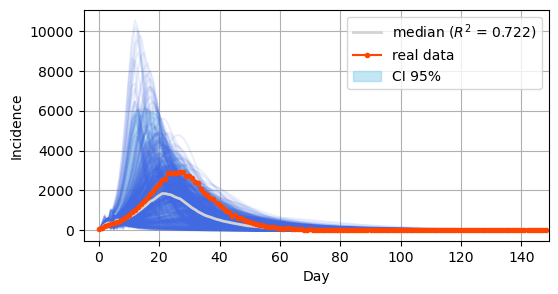

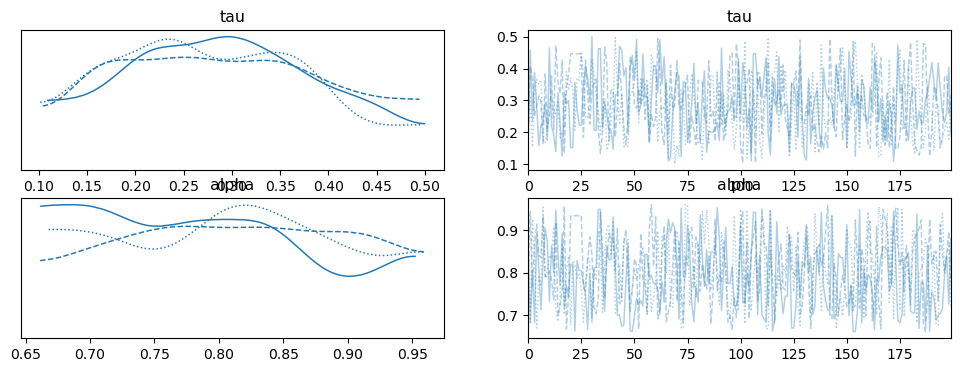

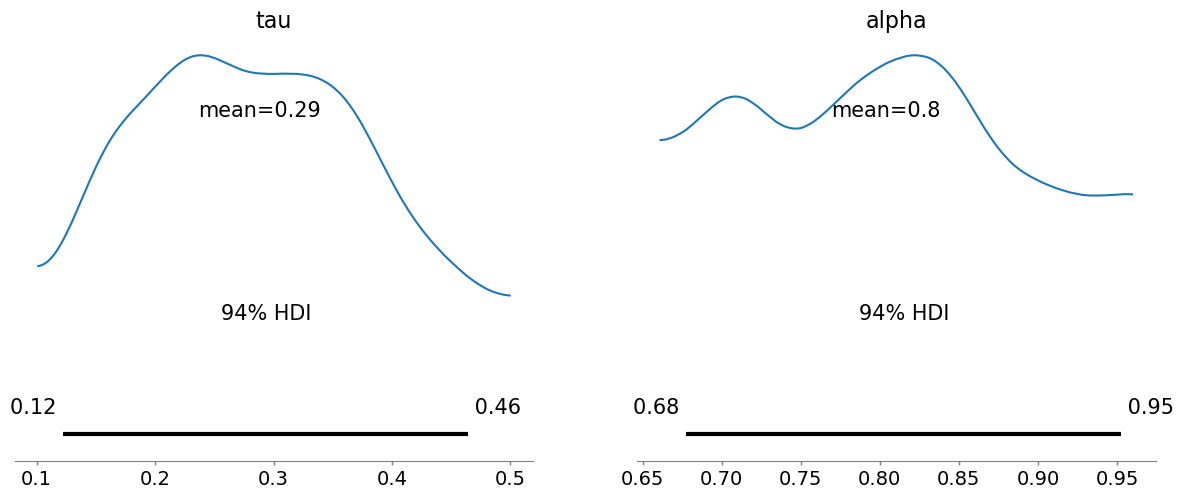

In [62]:
plot_funcs.plots(idata, observed_data['incidence'].values, '', 
                 simulation_func, for_pred=False, with_trace=True)


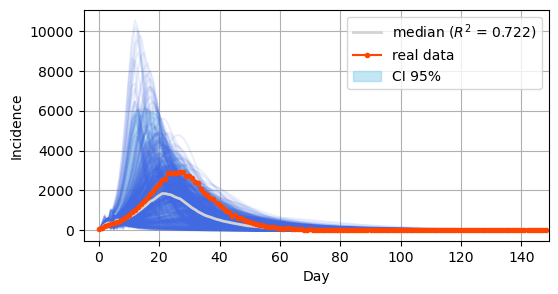

In [63]:
plot_funcs.plots(idata, observed_data['incidence'].values, '', 
                 simulation_func, for_pred=False, with_trace=False)
plt.savefig(f'results/ba_calib.pdf', format='pdf', bbox_inches='tight')

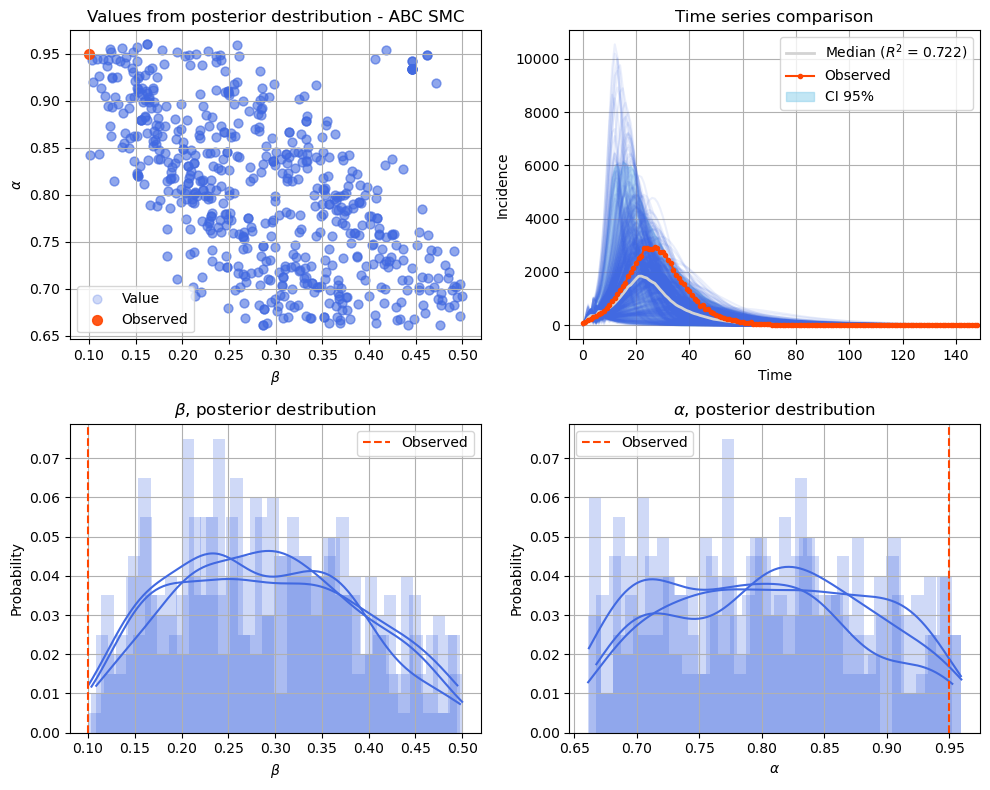

In [65]:
plot_funcs.results_calib(observed_data, idata, 
                         true_tau, true_alpha)
plt.savefig(f'results/ba_calib.pdf', format='pdf', bbox_inches='tight')

In [66]:
idata.posterior.to_netcdf('ba_p.h5', engine='scipy')
idata.posterior_predictive.to_netcdf('ba_pp.h5', engine='scipy')

[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\importlib\__init__.py", line 128, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,0.743,0.089,0.596,0.927,0.013,0.006,46.0,71.0,1.18
alpha,0.796,0.053,0.708,0.869,0.008,0.004,45.0,31.0,1.06


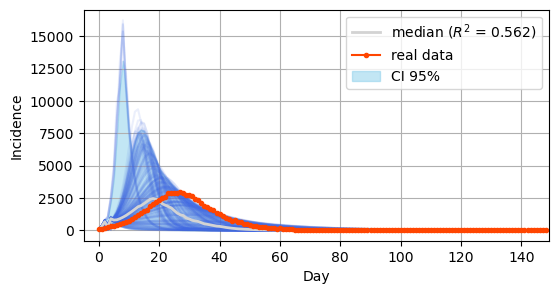

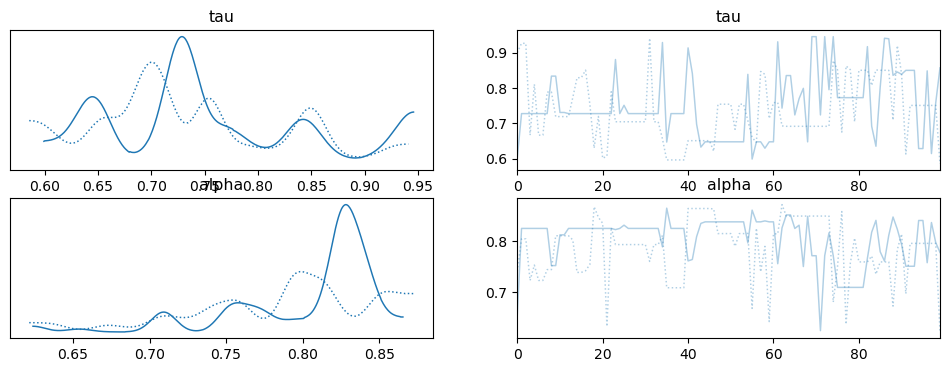

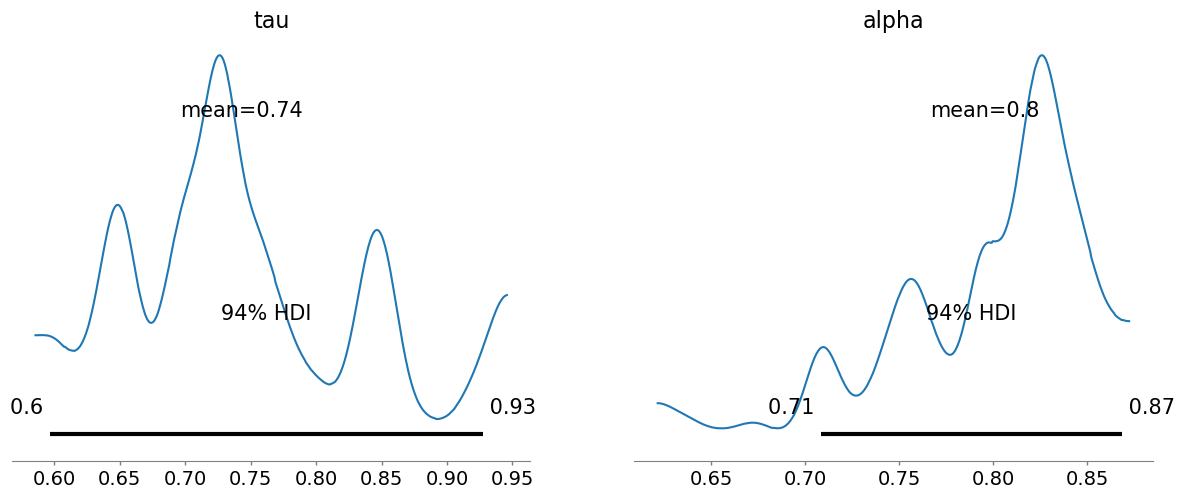

In [59]:
plot_funcs.plots(idata, observed_data['incidence'].values, '', 
                 simulation_func, for_pred=False, with_trace=True)
